## 1. Create data

In [1]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
X.shape, y.shape

((1000, 2), (1000,))

In [4]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
                    "X2":X[:,1],
                    "label":y})

circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
5,-0.469885,0.708037,1
6,-0.016045,0.805623,1
7,0.759623,0.159526,1
8,-0.175692,-0.799837,1
9,-0.110616,1.042207,0


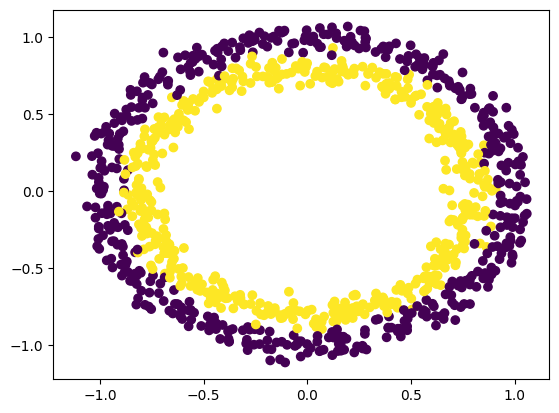

In [5]:
import matplotlib.pyplot as plt
plt.scatter(circles['X1'],
            circles['X2'],
            c=circles['label'])
plt.show()    

### 1.1 Turn data into tesnors

In [6]:
import torch 
torch.__version__

'2.11.0+cpu'

In [7]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
# X = torch.hstack([X,X**2]) acc in epoch 90 = 75%
X[:5], y[:5]

(tensor([[ 0.7422,  0.2467],
         [-0.7340,  0.1687],
         [-0.8299,  0.2220],
         [-0.4291,  0.6722],
         [ 0.4456, -0.8949]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
# Split data into training/test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
                                                    

In [9]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [10]:
type(X_train), type(y_train), type(X_test), type(y_test)

(torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor)

## 2. Building a model

In [11]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
X_train.shape

torch.Size([800, 2])

In [13]:
class CircleModelV0(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)      
        self.layer_2 = nn.Linear(in_features=10, out_features=1)

        # self.two_linear_layer = nn.Sequential(
        #     nn.Linear(in_features=2, out_features=10),
        #     nn.Linear(in_features=10, out_features=1)
        #     )

    def forward(self, x:torch.Tensor):
        z1 = self.layer_1(x)
        z2 = self.relu_2(z1)

        return z2
        # return self.two_linear_layer(x)

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

In [14]:
# Create model above with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=1)
)
model_0.to(device)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=1, bias=True)
)

In [15]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3013,  0.2891],
                      [-0.6809, -0.5646],
                      [ 0.1012,  0.3067],
                      [-0.1704, -0.2227],
                      [-0.5488,  0.6415],
                      [-0.1603,  0.2453],
                      [ 0.6525,  0.4108],
                      [ 0.1752, -0.2987],
                      [-0.0461, -0.3886],
                      [-0.5514, -0.2582]])),
             ('0.bias',
              tensor([-0.1271, -0.1035,  0.0612, -0.4931, -0.2646,  0.4810,  0.3345,  0.4148,
                       0.5836,  0.4923])),
             ('1.weight',
              tensor([[ 0.0948,  0.2698,  0.1572,  0.1386, -0.0085, -0.2949, -0.0918, -0.3159,
                        0.2901, -0.1524]])),
             ('1.bias', tensor([0.0104]))])

In [16]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
untrained_preds.shape, y_test.shape

(torch.Size([200, 1]), torch.Size([200]))

In [17]:
untrained_preds[:10]

tensor([[-0.3544],
        [-0.4967],
        [-0.0882],
        [-0.4399],
        [-0.2177],
        [-0.3084],
        [-0.5908],
        [-0.5506],
        [-0.0691],
        [-0.4991]])

### 2.1 Setup loss & optimizer

In [18]:
# Setup the loss function 

# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_0.parameters(), 
                                lr=0.1)

In [19]:
# Calculate accuracy 
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 3. Train phase

### 3.1 Prediction labels

In [20]:
## Eval model 
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.3544],
        [-0.4967],
        [-0.0882],
        [-0.4399],
        [-0.2177]])

In [21]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [22]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4123],
        [0.3783],
        [0.4780],
        [0.3918],
        [0.4458]])

* `y_pred_probs` >= 0.5 `y=1` (class 1)

* `y_pred_probs` < 0.5 `y=0` (class 0)


In [23]:
y_preds = torch.round(y_pred_probs)

# In one line
y_predv2 = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(),y_predv2.squeeze()))

tensor([True, True, True, True, True])


### 3.2 Train model

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities
    #                 y_train)

    loss = loss_fn(y_logits, # nn.BCEWithLogistLoss expects raw logits as input
                    y_train)
    acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits,
                            y_test)
    test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70949, Acc:48.25% | Test loss: 0.70152 | Test acc: 46.50%
Epoch: 10 | Loss: 0.69936, Acc:45.25% | Test loss: 0.69346 | Test acc: 50.00%
Epoch: 20 | Loss: 0.69611, Acc:47.50% | Test loss: 0.69160 | Test acc: 52.00%
Epoch: 30 | Loss: 0.69477, Acc:48.25% | Test loss: 0.69139 | Test acc: 52.50%
Epoch: 40 | Loss: 0.69409, Acc:47.25% | Test loss: 0.69164 | Test acc: 52.50%
Epoch: 50 | Loss: 0.69369, Acc:47.75% | Test loss: 0.69201 | Test acc: 53.50%
Epoch: 60 | Loss: 0.69344, Acc:47.38% | Test loss: 0.69240 | Test acc: 53.50%
Epoch: 70 | Loss: 0.69328, Acc:48.12% | Test loss: 0.69275 | Test acc: 52.50%
Epoch: 80 | Loss: 0.69318, Acc:44.00% | Test loss: 0.69307 | Test acc: 48.50%
Epoch: 90 | Loss: 0.69311, Acc:49.00% | Test loss: 0.69334 | Test acc: 46.00%


## 4. Improving a model (from a model prespoctive)
* Add model layers
* Add more hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function 

### 4.1 Improve model:
* Adding hidden units: 10 --> 20
* Increase the number of layer: 2 --> 3
* Increate number of epochs: 100 --> 300

In [26]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)
    
    def forward(self, x:torch.Tensor):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z

        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1()
model_1        

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=1, bias=True)
)

In [27]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer 
optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.1)

In [31]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 300

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Trainings
    model_1.train()

    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 30 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

        

Epoch: 0 | Loss: 0.70230, Acc:50.00% | Test loss: 0.70127 | Test acc: 50.00%
Epoch: 30 | Loss: 0.69336, Acc:46.62% | Test loss: 0.69352 | Test acc: 45.50%
Epoch: 60 | Loss: 0.69307, Acc:49.62% | Test loss: 0.69381 | Test acc: 49.00%
Epoch: 90 | Loss: 0.69301, Acc:51.12% | Test loss: 0.69414 | Test acc: 47.50%
Epoch: 120 | Loss: 0.69299, Acc:51.00% | Test loss: 0.69434 | Test acc: 46.00%
Epoch: 150 | Loss: 0.69298, Acc:51.12% | Test loss: 0.69447 | Test acc: 46.00%
Epoch: 180 | Loss: 0.69298, Acc:51.12% | Test loss: 0.69455 | Test acc: 46.00%
Epoch: 210 | Loss: 0.69298, Acc:51.25% | Test loss: 0.69459 | Test acc: 46.00%
Epoch: 240 | Loss: 0.69298, Acc:51.50% | Test loss: 0.69462 | Test acc: 45.50%
Epoch: 270 | Loss: 0.69298, Acc:51.50% | Test loss: 0.69464 | Test acc: 45.50%


### 4.2 Improve model with non-linearity
* Linear = straight line
* Non-linear = non-straight line

ANN are large combination of linear and non-linear function wich are potentially able to find patterns in data 

In [71]:
# Build a model with non-linear activation function


class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)

        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2()
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)

In [72]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(),
                                lr=0.1)

In [73]:
# Set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    ### Training
    model_2.train()

    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69450, Acc:48.00% | Test loss: 0.69199 | Test acc: 53.50%
Epoch: 100 | Loss: 0.69099, Acc:53.12% | Test loss: 0.68981 | Test acc: 56.00%
Epoch: 200 | Loss: 0.68743, Acc:57.00% | Test loss: 0.68742 | Test acc: 57.50%
Epoch: 300 | Loss: 0.68359, Acc:60.00% | Test loss: 0.68405 | Test acc: 59.50%
Epoch: 400 | Loss: 0.67792, Acc:63.38% | Test loss: 0.67883 | Test acc: 63.50%
Epoch: 500 | Loss: 0.66857, Acc:68.50% | Test loss: 0.67044 | Test acc: 69.50%
Epoch: 600 | Loss: 0.65247, Acc:74.38% | Test loss: 0.65644 | Test acc: 76.50%
Epoch: 700 | Loss: 0.62294, Acc:82.62% | Test loss: 0.63158 | Test acc: 81.50%
Epoch: 800 | Loss: 0.56699, Acc:91.88% | Test loss: 0.58518 | Test acc: 88.50%
Epoch: 900 | Loss: 0.46940, Acc:95.38% | Test loss: 0.50469 | Test acc: 92.00%


## 5. Replicating non-linear activation functions

In [76]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

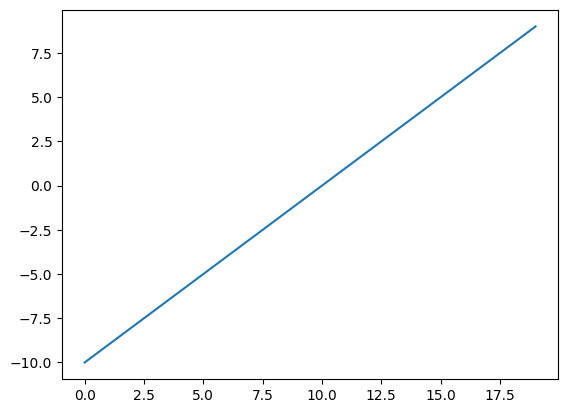

In [79]:
# Visualize the tensor
plt.plot(A);

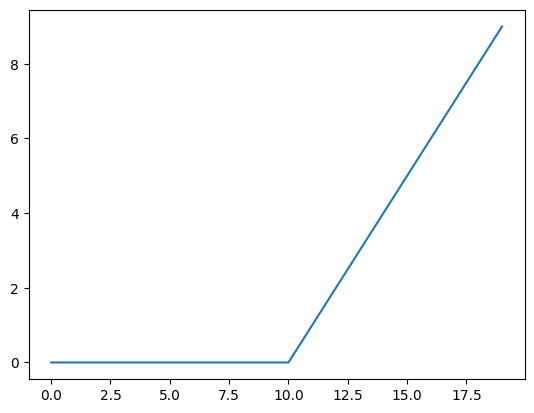

In [81]:
plt.plot(torch.relu(A));

In [82]:
def relu(x):
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

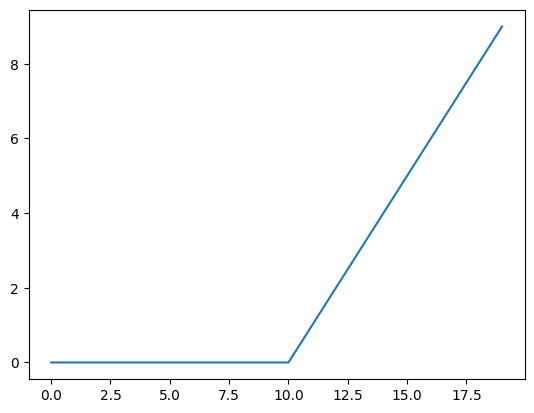

In [83]:
plt.plot(relu(A));

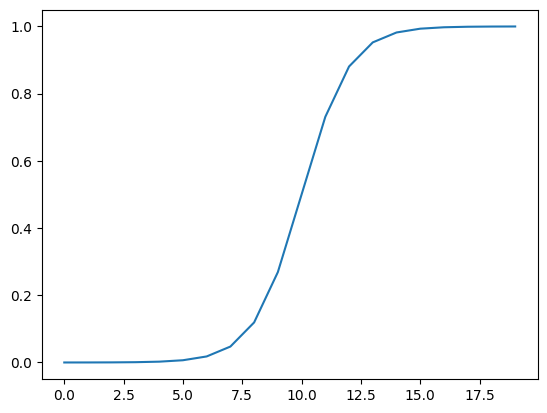

In [85]:
plt.plot(torch.sigmoid(A));

In [86]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

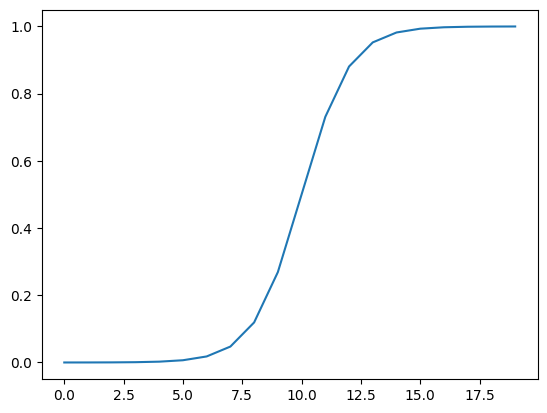

In [89]:
plt.plot(sigmoid(A));

## 6. Putting it all together with a multi-class classification problem

### 6.1 Data

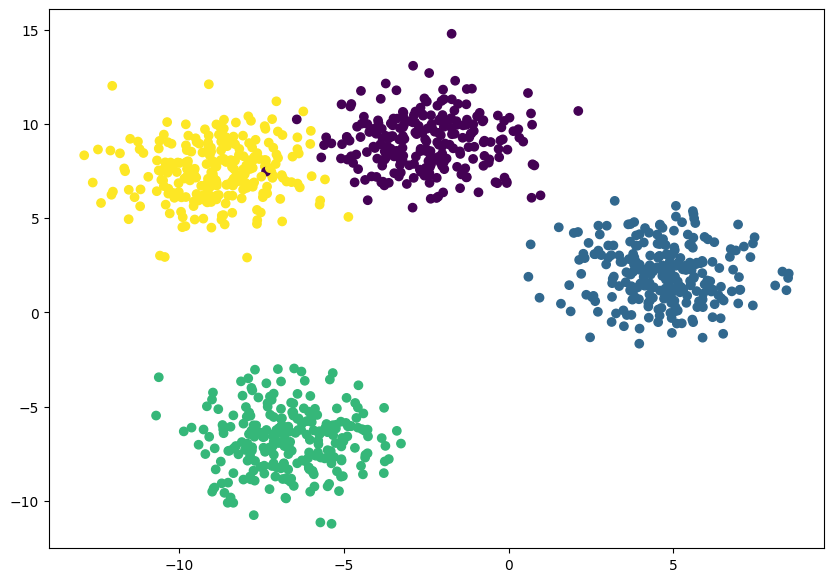

In [119]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameter for data creation
NUM_CLASSES = 4
NUM_FEATURE = 2
RANDOM_SEED = 42

# Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURE,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)
# Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# Split into train/test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob);

### 6.2 Model

In [120]:
# Create device agonstic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [121]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """
            Initializes multi-class classfication model.

            Args:
                input_features (int): Number of input features to the model
                output_features (int): Number of outputs features (number of otuput classes)
                hidden_units (int): Number of hidden units between layers, default 8
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

model_3 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_3

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 6.3 Loss function & optimizer

In [122]:
# Loss function for multi-class classfication
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(model_3.parameters(),
                                lr=0.1)

### 6.4 Getting prediction probabilites a multi-class

In [123]:
len(X_blob_train), len(X_blob_test), len(y_blob_train), len(y_blob_test)

(800, 200, 800, 200)

In [124]:
model_3.eval()
with torch.inference_mode():
    y_logits = model_3(X_blob_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [125]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [126]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [127]:
torch.sum(y_pred_probs[0])

tensor(1.)

In [128]:
torch.max(y_pred_probs[0])

tensor(0.3244)

In [129]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [130]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 6.5 Creating a trainng/testing loop

In [131]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# Put data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training 
    model_3.train()

    y_logits = model_3(X_blob_train)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_blob_train, y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_blob_test, test_preds)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
    


Epoch: 0 | Loss: 1.15883, Acc:40.38% | Test loss: 1.07554 | Test acc: 48.00%
Epoch: 10 | Loss: 0.64476, Acc:96.75% | Test loss: 0.66069 | Test acc: 97.50%
Epoch: 20 | Loss: 0.42535, Acc:98.50% | Test loss: 0.43074 | Test acc: 100.00%
Epoch: 30 | Loss: 0.25294, Acc:99.12% | Test loss: 0.24508 | Test acc: 99.50%
Epoch: 40 | Loss: 0.11232, Acc:99.25% | Test loss: 0.10229 | Test acc: 99.50%
Epoch: 50 | Loss: 0.06627, Acc:99.25% | Test loss: 0.05848 | Test acc: 99.50%
Epoch: 60 | Loss: 0.05068, Acc:99.25% | Test loss: 0.04293 | Test acc: 99.50%
Epoch: 70 | Loss: 0.04300, Acc:99.25% | Test loss: 0.03491 | Test acc: 99.50%
Epoch: 80 | Loss: 0.03836, Acc:99.25% | Test loss: 0.02988 | Test acc: 99.50%
Epoch: 90 | Loss: 0.03525, Acc:99.25% | Test loss: 0.02663 | Test acc: 99.50%
